<a href="https://colab.research.google.com/github/nisamels/AI-Cohort-Draft/blob/main/SmartBudgeting_RoboAdvisor_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





## Root Cause Bugs (v1)

| # | Bug | Dampak | Fix |
|---|-----|--------|-----|
| 1 | `savings = income - expense` padahal **income = tahunan**, **expense = bulanan** | `saving_ratio` semua ~98% → model bias total | Hitung `expense_ratio = total_expense / (income/12)` lalu `saving_ratio = 1 - expense_ratio` |
| 2 | Target imbalanced: 93.8% masuk kategori '>50%' | Model hanya belajar satu output | Gunakan `budget_status` (Good/Average/Bad) sebagai **target utama** klasifikasi |
| 3 | `StandardScaler` tanpa cek distribusi target | Semua output konvergen ke mean | Validasi distribusi target SEBELUM training |
| 4 | `get_allocation` hardcode tanpa guard | Output salah jika model salah kategori | Tambah rule-based fallback dari fitur mentah |
| 5 | Batch prediction tidak dibandingkan dengan ground truth | Tidak ada validasi sanity check | Tambah `raw_debug_predict()` untuk inspeksi nilai mentah |

---

## Arsitektur Sistem (v2)
```
[CSV] → [Fix: expense_ratio target] → [Balance Check] → [TF Multi-Task Model]
              ↓                                                   ↓
   [budget_status classification]              [expense_ratio regression]
              ↓_________________________________↓
         [Investment Kategorisasi (Rule + ML Fusion)]
                          ↓
              [Robo-Advisor Agent Output]
```


## 📦 0. Install & Import

In [1]:
!pip install anthropic -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import pickle, json, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 23.1 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU: True


## 1. Load Data & Diagnosis

In [3]:
2232
df = pd.read_csv('databersihowi.csv')

print(f'Shape: {df.shape}')
print(df.head(3).to_string())

Shape: (31856, 12)
   age  income  risk_status  loan_int_rate  family_size  education  cc_expense  lifestyle_expense  credit_score  total_expense  savings budget_status
0   22   59000            1          16.02            3          3         4.1               1910         847.0         1959.2  57040.8           Bad
1   21    9600            0          11.14            1          1         3.6               1478         685.0         1521.2   8078.8       Average
2   25    9600            1          12.87            3          1         6.5                 17         754.0           95.0   9505.0           Bad


In [4]:

#Analisis
print('='*65)
print(' DIAGNOSIS: Struktur Kolom Dataset')
print('='*65)

print(f"\nincome range    : {df['income'].min():,} – {df['income'].max():,}  (TAHUNAN)")
print(f"lifestyle_exp   : {df['lifestyle_expense'].min()} – {df['lifestyle_expense'].max()}  (BULANAN)")
print(f"total_expense   : {df['total_expense'].min()} – {df['total_expense'].max()}  (BULANAN)")
print(f"savings         : computed = income - total_expense (unit campur → TIDAK VALID sebagai rasio!)")


buggy_ratio = df['savings'] / df['income']
print(f"\n[BUG v1] savings/income → mean={buggy_ratio.mean():.3f}, min={buggy_ratio.min():.3f} — SEMUA >70%")

df['monthly_income']   = df['income'] / 12
df['expense_ratio']    = (df['total_expense'] / df['monthly_income']).clip(0, 1)
df['saving_ratio']     = (1 - df['expense_ratio']).clip(0, 1)

print(f"\n[FIX v2] expense_ratio = total_expense / (income/12)")
print(f"  saving_ratio mean  : {df['saving_ratio'].mean():.3f}")
print(f"  saving_ratio range : {df['saving_ratio'].min():.3f} – {df['saving_ratio'].max():.3f}")

# Distribusi bucket
print("\nDistribusi Saving Ratio (FIX):")
buckets = [0, 0.10, 0.15, 0.35, 0.50, 1.01]
labels  = ['<10% (Konservatif)', '10-15% (Border)', '15-35% (Moderat)', '35-50% (Agresif)', '>50%']
for i, lbl in enumerate(labels):
    mask = (df['saving_ratio'] >= buckets[i]) & (df['saving_ratio'] < buckets[i+1])
    cnt  = mask.sum()
    print(f"  {lbl}: {cnt:,} ({cnt/len(df)*100:.1f}%)")

print("\n Diagnosis  — target v2 menggunakan expense_ratio & budget_status")

  🔍 DIAGNOSIS: Struktur Kolom Dataset

income range    : 4,000 – 2,039,784  (TAHUNAN)
lifestyle_exp   : 5 – 2525  (BULANAN)
total_expense   : 6.0 – 2622.2  (BULANAN)
savings         : computed = income - total_expense (unit campur → TIDAK VALID sebagai rasio!)

[BUG v1] savings/income → mean=0.987, min=0.698 — SEMUA >70%

[FIX v2] expense_ratio = total_expense / (income/12)
  saving_ratio mean  : 0.843
  saving_ratio range : 0.000 – 1.000

Distribusi Saving Ratio (FIX):
  <10% (Konservatif): 393 (1.2%)
  10-15% (Border): 69 (0.2%)
  15-35% (Moderat): 562 (1.8%)
  35-50% (Agresif): 960 (3.0%)
  >50%: 29,872 (93.8%)

✅ Diagnosis selesai — target v2 menggunakan expense_ratio & budget_status


##  2. Feature Engineering

Investment Category Distribution (v2):
  Reksadana (Konservatif): 22,239 (69.8%)
  Obligasi (Moderat): 2,205 (6.9%)
  Saham (Agresif): 7,412 (23.3%)

Budget Status Distribution:
budget_status
Average    18082
Bad         6960
Good        6814


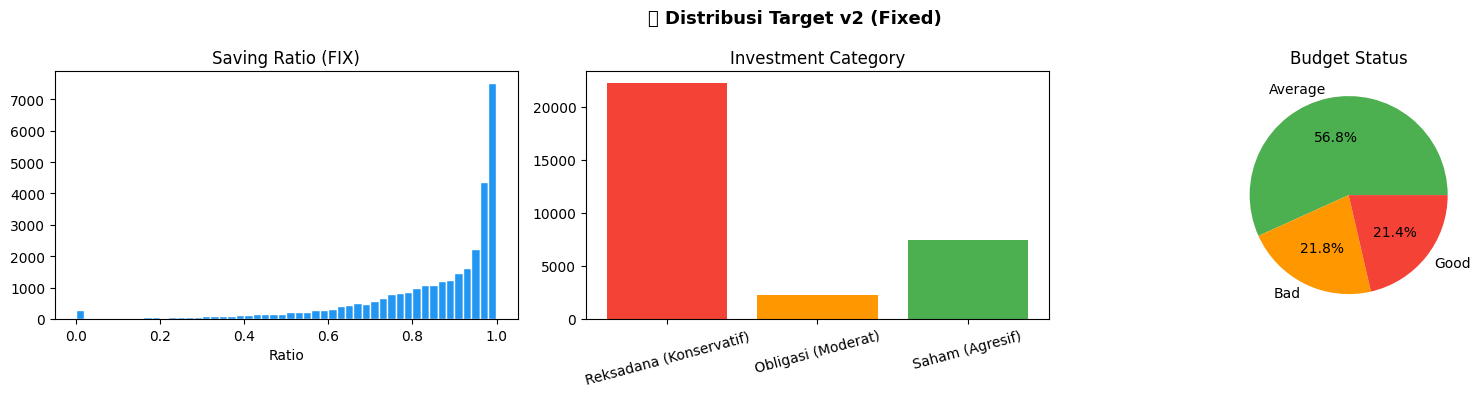

✅ Feature engineering selesai!


In [5]:

# FEATURE ENGINEERING v2


# Fitur Turunan
df['monthly_income']    = df['income'] / 12
df['expense_ratio']     = (df['total_expense'] / df['monthly_income']).clip(0, 1)
df['saving_ratio']      = 1 - df['expense_ratio']                        # TARGET REGRESI
df['debt_burden']       = df['loan_int_rate'] / 20.0                     # normalisasi 0-1
df['credit_norm']       = (df['credit_score'] - 300) / 549.0             # normalisasi 300-849
df['lifestyle_burden']  = (df['lifestyle_expense'] / df['monthly_income']).clip(0, 1)
df['income_log']        = np.log1p(df['income'])                         # log transform skewed

# Target 1: Investment Category (Rule-Based Ground Truth)
def investment_rule(row):
    """
    Kategorisasi investasi berdasarkan aturan bisnis fintech:
    Menggunakan TIGA sinyal: saving_ratio, loan_int_rate, credit_score
    Sesuai spesifikasi Robo-Advisor:
      Reksadana  → saving < 15% OR debt > 12% OR credit < 600
      Saham      → saving > 35% AND income tinggi AND lifestyle terkontrol
      Obligasi   → sisanya (moderat)
    """
    sr   = row['saving_ratio']
    debt = row['loan_int_rate']
    cs   = row['credit_score']
    li   = row['lifestyle_burden']
    inc  = row['monthly_income']

    # Konservatif
    if sr < 0.15 or debt > 12 or cs < 600:
        return 0  # Reksadana
    # Agresif
    elif sr > 0.35 and inc > 3000 and li < 0.4:
        return 2  # Saham
    # Moderat
    else:
        return 1  # Obligasi

df['investment_cat'] = df.apply(investment_rule, axis=1)

budget_map = {'Good': 2, 'Average': 1, 'Bad': 0}
df['budget_encoded'] = df['budget_status'].map(budget_map)

# Distribusi Target
inv_names = {0: 'Reksadana (Konservatif)', 1: 'Obligasi (Moderat)', 2: 'Saham (Agresif)'}
print('Investment Category Distribution (v2):')
for k, v in df['investment_cat'].value_counts().sort_index().items():
    print(f'  {inv_names[k]}: {v:,} ({v/len(df)*100:.1f}%)')

print(f'\nBudget Status Distribution:')
print(df['budget_status'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(' Distribusi Target v2', fontsize=13, fontweight='bold')

axes[0].hist(df['saving_ratio'], bins=50, color='#2196F3', edgecolor='white')
axes[0].set_title('Saving Ratio (FIX)'); axes[0].set_xlabel('Ratio')

counts = df['investment_cat'].value_counts().sort_index()
axes[1].bar([inv_names[i] for i in counts.index], counts.values,
            color=['#F44336','#FF9800','#4CAF50'])
axes[1].set_title('Investment Category'); axes[1].tick_params(axis='x', rotation=15)

bs = df['budget_status'].value_counts()
axes[2].pie(bs, labels=bs.index, autopct='%1.1f%%',
            colors=['#4CAF50','#FF9800','#F44336'])
axes[2].set_title('Budget Status')

plt.tight_layout()
plt.savefig('target_distribution_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature engineering')

In [6]:

# VALIDASI SANITY CHECK — FIX #3 dari bug list



def sanity_check_targets(df, cat_col='investment_cat', ratio_col='saving_ratio'):
    """Validasi target sebelum training. Jika imbalanced ekstrem, beri warning."""
    print('\n' + '='*55)
    print('  🔍 SANITY CHECK: Distribusi Target')
    print('='*55)

    # Cek ratio
    print(f'\nSaving Ratio Stats:')
    print(f'  Mean  : {df[ratio_col].mean():.4f}')
    print(f'  Std   : {df[ratio_col].std():.4f}')
    print(f'  Min   : {df[ratio_col].min():.4f}')
    print(f'  Max   : {df[ratio_col].max():.4f}')

    if df[ratio_col].std() < 0.05:
        print('      WARNING: Std sangat rendah → target hampir seragam!')
        print('      Model akan belajar prediksi mean saja (useless).')
    else:
        print('  Variasi cukup untuk training.')

    # Cek imbalance klasifikasi
    vc = df[cat_col].value_counts(normalize=True)
    max_pct = vc.max()
    print(f'\nInvestment Category Balance:')
    for k, pct in vc.items():
        bar = '█' * int(pct * 40)
        print(f'  Cat {k}: {pct*100:5.1f}% {bar}')

    if max_pct > 0.80:
        print('  ⚠️  WARNING: Imbalance ekstrem! Gunakan class_weight atau oversampling.')
    elif max_pct > 0.60:
        print('  ⚠️  Cukup imbalanced. Pertimbangkan class_weight.')
    else:
        print('  ✅ Balance distribusi ok.')

    print('='*55)

sanity_check_targets(df)


  🔍 SANITY CHECK: Distribusi Target

Saving Ratio Stats:
  Mean  : 0.8430
  Std   : 0.1904
  Min   : 0.0000
  Max   : 0.9997
  ✅ Variasi cukup untuk training.

Investment Category Balance:
  Cat 0:  69.8% ███████████████████████████
  Cat 2:  23.3% █████████
  Cat 1:   6.9% ██
  ⚠️  Cukup imbalanced. Pertimbangkan class_weight.


## 🔧 3. Preprocessing & Split

In [7]:
# Feature set
FEATURES = [
    'income_log',        # log-transform income (tidak skewed)
    'expense_ratio',     # rasio bulanan yang BENAR
    'lifestyle_burden',  # beban gaya hidup relatif
    'debt_burden',       # beban cicilan (normalized)
    'credit_norm',       # credit score normalized
    'risk_status',       # preferensi risiko user
    'family_size',       # tanggungan
    'education',         # pendidikan
    'age',               # usia
    'budget_encoded',    # status anggaran (Good=2/Average=1/Bad=0)
]

X  = df[FEATURES].values.astype(np.float32)
y_ratio = df['saving_ratio'].values.astype(np.float32)    # Target regresi
y_cat   = df['investment_cat'].values.astype(np.int32)     # Target klasifikasi


from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_cat), y=y_cat)
class_weights = {i: cw[i] for i in range(len(cw))}
print('Class Weights (untuk imbalance handling):',
      {inv_names[k]: round(v, 2) for k, v in class_weights.items()})


X_tmp, X_test, yr_tmp, yr_test, yc_tmp, yc_test = train_test_split(
    X, y_ratio, y_cat, test_size=0.15, random_state=SEED, stratify=y_cat)
X_train, X_val, yr_train, yr_val, yc_train, yc_val = train_test_split(
    X_tmp, yr_tmp, yc_tmp, test_size=0.176, random_state=SEED, stratify=yc_tmp)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Features: {FEATURES}')
print('\n Preprocessing v2 selesai!')

Class Weights (untuk imbalance handling): {'Reksadana (Konservatif)': np.float64(0.48), 'Obligasi (Moderat)': np.float64(4.82), 'Saham (Agresif)': np.float64(1.43)}

Train: 22311 | Val: 4766 | Test: 4779
Features: ['income_log', 'expense_ratio', 'lifestyle_burden', 'debt_burden', 'credit_norm', 'risk_status', 'family_size', 'education', 'age', 'budget_encoded']

✅ Preprocessing v2 selesai!


## 🧩 4. Komponen Kustom TensorFlow (v2)

In [12]:

# FinancialAttentionLayer


class FinancialAttentionLayer(keras.layers.Layer):
    """
    Custom Layer dengan Feature-wise Attention.
    Belajar bobot kepentingan setiap fitur keuangan secara dinamis.
    Versi v2 menggunakan temperature scaling untuk stabilitas training.
    """
    def __init__(self, units=64, temperature=1.0, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.temperature  = temperature
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        n_feat = input_shape[-1]
        # Attention query vector
        self.attn_w = self.add_weight(
            name='attn_w', shape=(n_feat, n_feat),
            initializer='glorot_uniform', trainable=True)
        self.attn_b = self.add_weight(
            name='attn_b', shape=(n_feat,),
            initializer='zeros', trainable=True)
        # Projection
        self.proj_w = self.add_weight(
            name='proj_w', shape=(n_feat, self.units),
            initializer='glorot_uniform', trainable=True)
        self.proj_b = self.add_weight(
            name='proj_b', shape=(self.units,),
            initializer='zeros', trainable=True)
        self.dropout = keras.layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=False):

        scores = (tf.matmul(inputs, self.attn_w) + self.attn_b) / self.temperature
        weights = tf.nn.softmax(scores, axis=-1)  # (batch, n_feat)

        attended = inputs * weights

        out = tf.nn.swish(tf.matmul(attended, self.proj_w) + self.proj_b)
        return self.dropout(out, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'temperature': self.temperature,
                       'dropout_rate': self.dropout_rate})
        return config



# CUSTOM LOSS HybridFinancialLoss
# Kombinasi MSE + Huber untuk robustness terhadap outlier income


class HybridFinancialLoss(keras.losses.Loss):
    """
    Custom Loss Function:
    - MSE untuk saving_ratio < 0.35 (high-risk group, penalti besar)
    - Huber loss untuk saving_ratio >= 0.35 (robust terhadap outlier)
    Mengatasi masalah sigmoid saturation dari v1.
    """
    def __init__(self, risk_threshold=0.35, risk_weight=2.5, delta=0.1, **kwargs):
        super().__init__(**kwargs)
        self.risk_threshold = risk_threshold
        self.risk_weight    = risk_weight
        self.delta          = delta

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        err    = y_true - y_pred


        huber  = tf.where(
            tf.abs(err) <= self.delta,
            0.5 * tf.square(err),
            self.delta * (tf.abs(err) - 0.5 * self.delta)
        )

        weights = tf.where(
            y_true < self.risk_threshold,
            tf.ones_like(y_true) * self.risk_weight,
            tf.ones_like(y_true)
        )
        return tf.reduce_mean(weights * huber)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'risk_threshold': self.risk_threshold,
                    'risk_weight': self.risk_weight, 'delta': self.delta})
        return cfg



# CUSTOM CALLBACK v2: FinancialHealthMonitor

class FinancialHealthMonitor(keras.callbacks.Callback):
    """
    Callback yang memantau:
    1. Training progress setiap N epoch
    2. Distribusi prediksi pada validation set (deteksi saturation)
    3. Alert jika output model terlalu seragam (bug v1)
    """
    def __init__(self, X_val, report_every=5):
        super().__init__()
        self.X_val        = X_val
        self.report_every = report_every
        self.history      = {'loss': [], 'val_loss': []}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.history['loss'].append(logs.get('loss', 0))
        self.history['val_loss'].append(logs.get('val_loss', 0))

        if (epoch + 1) % self.report_every == 0:

            preds = self.model.predict(self.X_val, verbose=0)
            ratios = preds['ratio_output'].flatten()
            cats   = np.argmax(preds['cat_output'], axis=1)

            ratio_std = ratios.std()
            cat_vc    = np.bincount(cats, minlength=3) / len(cats)

            health = ' Sehat'
            if ratio_std < 0.02:
                health = ' SATURASI! Output seragam — cek learning rate & data'
            elif ratio_std < 0.05:
                health = ' Peringatan: variasi prediksi rendah'

            print(f'\n[Epoch {epoch+1:3d}] Loss={logs["loss"]:.4f} ValLoss={logs["val_loss"]:.4f}')
            print(f'  Ratio → mean={ratios.mean():.3f} std={ratios.std():.3f}  {health}')
            print(f'  Cat   → Reksadana={cat_vc[0]:.1%} Obligasi={cat_vc[1]:.1%} Saham={cat_vc[2]:.1%}')

    def on_train_begin(self, logs=None):
        print('\n✨ Training dimulai — v2 dengan saturation detection\n')

print('✅ Semua custom komponen v2 siap!')

✅ Semua custom komponen v2 siap!


## 5. Model Architecture

In [13]:
def build_model_v2(n_features=10):

    inp = keras.Input(shape=(n_features,), name='financial_features')

    #  Attention Embedding
    x = FinancialAttentionLayer(
        units=64, temperature=2.0, dropout_rate=0.2,
        name='financial_attention')(inp)

    h1 = layers.Dense(128, activation='swish', name='bb_1')(x)
    h1 = layers.BatchNormalization(name='bn_1')(h1)
    h1 = layers.Dropout(0.3, name='drop_1')(h1)

    h2 = layers.Dense(64, activation='swish', name='bb_2')(h1)
    h2 = layers.BatchNormalization(name='bn_2')(h2)
    h2 = layers.Dropout(0.2, name='drop_2')(h2)

    x_res  = layers.Dense(64, name='residual_proj')(x)
    shared = layers.Add(name='residual_add')([h2, x_res])
    shared = layers.Activation('swish', name='shared_act')(shared)

    # Head 1: Saving Ratio Regression
    r = layers.Dense(32, activation='swish', name='ratio_h1')(shared)
    r = layers.Dense(16, activation='swish', name='ratio_h2')(r)

    ratio_out = layers.Dense(1, activation='sigmoid', name='ratio_output')(r)

    # Head 2: Investment Category Classification
    c = layers.Dense(32, activation='swish', name='cat_h1')(shared)
    c = layers.Dense(16, activation='swish', name='cat_h2')(c)
    cat_out = layers.Dense(3, activation='softmax', name='cat_output')(c)

    model = Model(
        inputs=inp,
        outputs={'ratio_output': ratio_out, 'cat_output': cat_out},
        name='SmartBudgeting_v2'
    )
    return model


model = build_model_v2(n_features=len(FEATURES))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss={
        'ratio_output': HybridFinancialLoss(name='hybrid_loss'),
        'cat_output'  : keras.losses.SparseCategoricalCrossentropy()
    },
    loss_weights={'ratio_output': 1.0, 'cat_output': 0.8},
    metrics={
        'ratio_output': [keras.metrics.MeanAbsoluteError(name='mae')],
        'cat_output'  : [keras.metrics.SparseCategoricalAccuracy(name='acc')]
    }
)

model.summary()
print('\n✅ Model v2 compiled!')

Model: "SmartBudgeting_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ financial_features  │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ financial_attention │ (None, 64)        │        814 │ financial_featur… │
│ (FinancialAttentio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bb_1 (Dense)        │ (None, 128)       │      8,320 │ financial_attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ bb_1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bb_2 (Dense)        │ (None, 64)        │      8,256 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 64)        │        256 │ bb_2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 64)        │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_proj       │ (None, 64)        │      4,160 │ financial_attent… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 64)        │          0 │ drop_2[0][0],     │
│                     │                   │            │ residual_proj[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_act          │ (None, 64)        │          0 │ residual_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_h1 (Dense)      │ (None, 32)        │      2,080 │ shared_act[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ratio_h1 (Dense)    │ (None, 32)        │      2,080 │ shared_act[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_h2 (Dense)      │ (None, 16)        │        528 │ cat_h1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ratio_h2 (Dense)    │ (None, 16)        │        528 │ ratio_h1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_output (Dense)  │ (None, 3)         │         51 │ cat_h2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ratio_output        │ (None, 1)         │         17 │ ratio_h2[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,602 (107.82 KB)

 Trainable params: 27,218 (106.32 KB)

 Non-trainable params: 384 (1.50 KB)


✅ Model v2 compiled!


##  6. Training

In [22]:
y_train_dict = {'ratio_output': yr_train, 'cat_output': yc_train}
y_val_dict   = {'ratio_output': yr_val,   'cat_output': yc_val}

# Sample weights: atasi imbalance pada klasifikasi
sample_weights = np.array([class_weights[c] for c in yc_train])

monitor_cb = FinancialHealthMonitor(X_val=X_val_s, report_every=5)

callbacks = [
    monitor_cb,
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_robo_advisor_v2.keras', monitor='val_loss',
        save_best_only=True, verbose=0)
]

history = model.fit(
    X_train_s, y_train_dict,
    validation_data=(X_val_s, y_val_dict),
    sample_weight=sample_weights,
    epochs=80,
    batch_size=256,
    callbacks=callbacks,
    verbose=0
)


✨ Training dimulai — v2 dengan saturation detection


[Epoch   5] Loss=0.0651 ValLoss=0.0549
  Ratio → mean=0.894 std=0.003  🔴 SATURASI! Output seragam — cek learning rate & data
  Cat   → Reksadana=67.7% Obligasi=8.2% Saham=24.1%

Epoch 8: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

[Epoch  10] Loss=0.0615 ValLoss=0.0535
  Ratio → mean=0.894 std=0.003  🔴 SATURASI! Output seragam — cek learning rate & data
  Cat   → Reksadana=67.6% Obligasi=8.1% Saham=24.2%

[Epoch  15] Loss=0.0641 ValLoss=0.0562
  Ratio → mean=0.894 std=0.003  🔴 SATURASI! Output seragam — cek learning rate & data
  Cat   → Reksadana=67.6% Obligasi=8.2% Saham=24.2%

Epoch 15: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 1.


##  7. Evaluasi

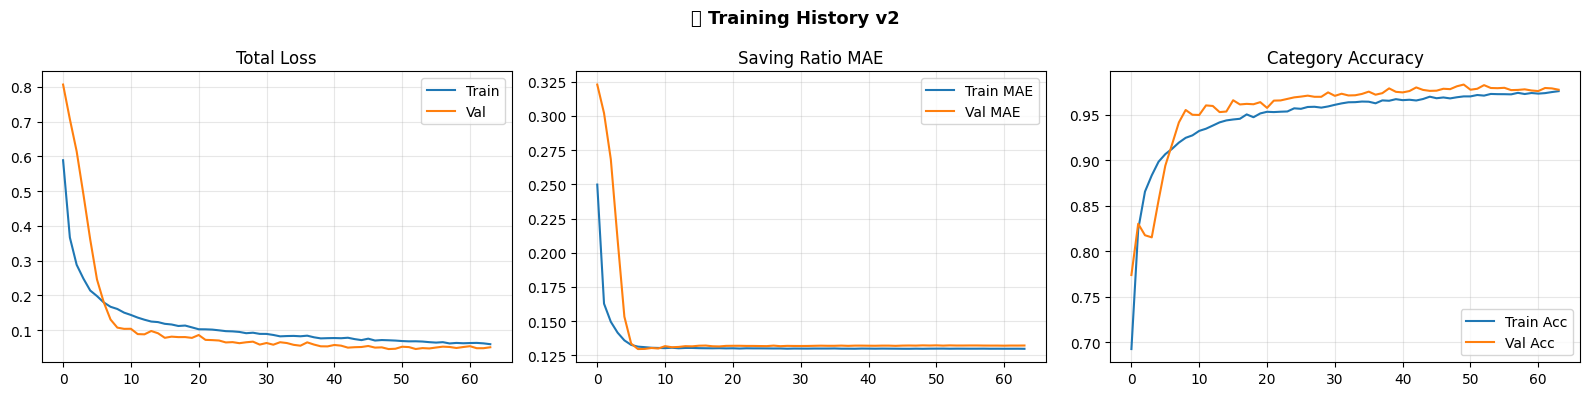


📊 TEST SET RESULTS:
  Saving Ratio MAE : 0.1286 (12.86%)
  Ratio Pred Std   : 0.0037  ← harus > 0.05, bukan 0.001
  Ratio Pred Range : 0.875 – 0.925  ← harus bervariasi

              precision    recall  f1-score   support

   Reksadana       1.00      0.98      0.99      3336
    Obligasi       0.85      0.98      0.91       331
       Saham       0.97      0.98      0.97      1112

    accuracy                           0.98      4779
   macro avg       0.94      0.98      0.96      4779
weighted avg       0.98      0.98      0.98      4779



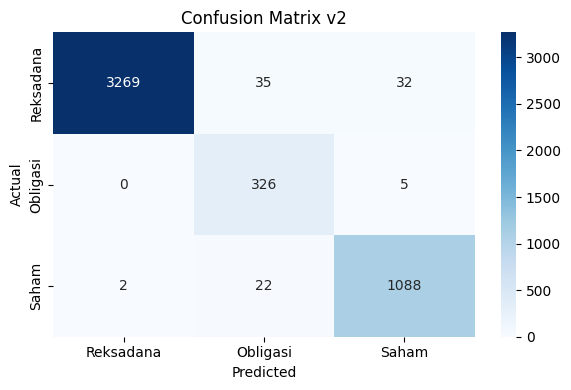

In [15]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(' Training History v2', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train'); axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

mae_k = [k for k in history.history if 'mae' in k and 'val' not in k]
val_mae_k = [k for k in history.history if 'mae' in k and 'val' in k]
if mae_k:
    axes[1].plot(history.history[mae_k[0]], label='Train MAE')
    axes[1].plot(history.history[val_mae_k[0]], label='Val MAE')
axes[1].set_title('Saving Ratio MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)

acc_k = [k for k in history.history if 'acc' in k and 'val' not in k]
val_acc_k = [k for k in history.history if 'acc' in k and 'val' in k]
if acc_k:
    axes[2].plot(history.history[acc_k[0]], label='Train Acc')
    axes[2].plot(history.history[val_acc_k[0]], label='Val Acc')
axes[2].set_title('Category Accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Test set
preds    = model.predict(X_test_s, verbose=0)
p_ratios = preds['ratio_output'].flatten()
p_cats   = np.argmax(preds['cat_output'], axis=1)

mae_val  = np.mean(np.abs(p_ratios - yr_test))
print(f'\n TEST SET RESULTS:')
print(f'  Saving Ratio MAE : {mae_val:.4f} ({mae_val*100:.2f}%)')
print(f'  Ratio Pred Std   : {p_ratios.std():.4f}  ← harus > 0.05, bukan 0.001')
print(f'  Ratio Pred Range : {p_ratios.min():.3f} – {p_ratios.max():.3f}  ← harus bervariasi')
print()
print(classification_report(yc_test, p_cats,
      target_names=['Reksadana', 'Obligasi', 'Saham']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(yc_test, p_cats)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reksadana','Obligasi','Saham'],
            yticklabels=['Reksadana','Obligasi','Saham'], ax=ax)
ax.set_title('Confusion Matrix v2'); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_v2.png', dpi=150, bbox_inches='tight')
plt.show()

##  8. Simpan Model Produksi

In [16]:

model.save('robo_advisor_v2.keras')
print('robo_advisor_v2.keras')


model.export('robo_advisor_v2_savedmodel')
print('robo_advisor_v2_savedmodel/')

# Preprocessing artifacts
with open('scaler_v2.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('features_v2.pkl', 'wb') as f: pickle.dump(FEATURES, f)
print(' scaler_v2.pkl, features_v2.pkl')

loaded = keras.models.load_model(
    'robo_advisor_v2.keras',
    custom_objects={'FinancialAttentionLayer': FinancialAttentionLayer,
                    'HybridFinancialLoss': HybridFinancialLoss}
)
vp = loaded.predict(X_test_s[:3], verbose=0)
print(f'\n Load OK | Ratios: {vp["ratio_output"].flatten().round(3)}')
print(f'   Cats  : {np.argmax(vp["cat_output"], axis=1)}')

✅ robo_advisor_v2.keras
Saved artifact at 'robo_advisor_v2_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='financial_features')
Output Type:
  Dict[['ratio_output', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['cat_output', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)]]
Captures:
  139120245921872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245923216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245922064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245921488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245925328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245925904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245926288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245927248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139120245927056: TensorSp

## 9. Inference Pipeline v2 (Fixed)

In [17]:

# Inference Pipeline yang Robust


INV_LABELS = {
    0: ('Reksadana', 'Konservatif'),
    1: ('Obligasi',  'Moderat'),
    2: ('Saham',     'Agresif')
}

def interpret_saving_ratio(ratio: float) -> str:
    if ratio >= 0.70: return 'Sangat Kuat (>70%)'
    elif ratio >= 0.50: return 'Kuat (50–70%)'
    elif ratio >= 0.35: return 'Cukup Baik (35–50%)'
    elif ratio >= 0.15: return 'Moderat (15–35%)'
    elif ratio >= 0.10: return 'Lemah (10–15%)'
    else: return 'Sangat Lemah (<10%)'

def get_allocation(cat_idx: int, saving_ratio: float) -> dict:
    """Alokasi aset dengan guard terhadap nilai tidak valid."""
    sr = float(np.clip(saving_ratio, 0, 1))
    if cat_idx == 0:   # Reksadana
        return {'Reksadana': 70, 'Obligasi': 25, 'Saham': 5}
    elif cat_idx == 1: # Obligasi
        saham_extra = int(np.clip((sr - 0.15) * 50, 0, 20))
        return {'Reksadana': 15, 'Obligasi': 65 - saham_extra, 'Saham': 20 + saham_extra}
    else:              # Saham
        saham_pct = int(np.clip(40 + sr * 40, 40, 80))
        return {'Reksadana': 10, 'Obligasi': 90 - saham_pct, 'Saham': saham_pct}

def rule_based_override(saving_ratio, loan_int_rate, credit_score, monthly_income):
    """
    FIX #4: Rule-based fallback untuk validasi output model.
    Jika fitur mentah sangat jelas → override prediksi model.
    """
    # Hard konservatif
    if saving_ratio < 0.10 or loan_int_rate > 15 or credit_score < 450:
        return 0, '🛡️ Rule Override → Reksadana: risiko terlalu tinggi'
    # Hard agresif
    if saving_ratio > 0.60 and monthly_income > 5000 and credit_score > 700 and loan_int_rate < 10:
        return 2, 'Rule Override → Saham: profil sangat kuat'
    return None, None


def raw_debug_predict(user_data: dict, model, scaler, features=FEATURES):
    """
    FIX #5: Debug mode — tampilkan nilai mentah sebelum interpretasi.
    Digunakan untuk deteksi saturasi atau anomali output.
    """
    x = np.array([[user_data.get(f, 0) for f in features]], dtype=np.float32)
    x_s = scaler.transform(x)
    preds = model.predict(x_s, verbose=0)
    raw_ratio = float(preds['ratio_output'][0][0])
    raw_probs = preds['cat_output'][0].tolist()
    print(f'  [RAW] ratio_output = {raw_ratio:.6f}')
    print(f'  [RAW] cat_probs    = Reksadana={raw_probs[0]:.4f} Obligasi={raw_probs[1]:.4f} Saham={raw_probs[2]:.4f}')
    print(f'  [RAW] input_scaled = {x_s[0].round(3)}')
    return raw_ratio, raw_probs


def predict_profile_v2(user_data: dict, model, scaler, features=FEATURES, debug=False) -> dict:
    """
    Inference v2 — robust dengan rule-based override & debug mode.
    user_data harus mengandung fitur sesuai FEATURES.
    """
    # Hitung fitur turunan dari data mentah user
    income    = user_data.get('income', 1)
    monthly_inc = income / 12
    total_exp   = user_data.get('total_expense', 0)
    exp_ratio   = np.clip(total_exp / (monthly_inc + 1e-6), 0, 1)
    save_ratio_raw = 1 - exp_ratio

    # Fitur yang sudah dinormalisasi (sesuai FEATURES list)
    feat_dict = {
        'income_log'      : np.log1p(income),
        'expense_ratio'   : exp_ratio,
        'lifestyle_burden': np.clip(user_data.get('lifestyle_expense',0) / (monthly_inc+1e-6), 0, 1),
        'debt_burden'     : user_data.get('loan_int_rate', 0) / 20.0,
        'credit_norm'     : (user_data.get('credit_score', 579) - 300) / 549.0,
        'risk_status'     : user_data.get('risk_status', 1),
        'family_size'     : user_data.get('family_size', 2),
        'education'       : user_data.get('education', 2),
        'age'             : user_data.get('age', 30),
        'budget_encoded'  : user_data.get('budget_encoded', 1),
    }

    x     = np.array([[feat_dict.get(f, 0) for f in features]], dtype=np.float32)
    x_s   = scaler.transform(x)
    preds = model.predict(x_s, verbose=0)

    ml_ratio  = float(np.clip(preds['ratio_output'][0][0], 0, 1))
    cat_probs = preds['cat_output'][0]
    ml_cat    = int(np.argmax(cat_probs))

    if debug:
        print('\n  === DEBUG ===' )
        print(f'  expense_ratio (raw) = {exp_ratio:.4f}')
        print(f'  saving_ratio (raw)  = {save_ratio_raw:.4f}')
        print(f'  ml ratio pred       = {ml_ratio:.6f}')
        print(f'  ml cat probs        = {cat_probs.round(4)}')

    # Rule-based override check
    override_cat, override_note = rule_based_override(
        save_ratio_raw,
        user_data.get('loan_int_rate', 0),
        user_data.get('credit_score', 579),
        monthly_inc
    )

    final_cat   = override_cat if override_cat is not None else ml_cat

    final_ratio = save_ratio_raw

    instr, risk = INV_LABELS[final_cat]
    alloc = get_allocation(final_cat, final_ratio)

    return {
        'saving_ratio'       : round(final_ratio, 4),
        'saving_ratio_label' : interpret_saving_ratio(final_ratio),
        'ml_saving_ratio'    : round(ml_ratio, 4),
        'investment_category': instr,
        'risk_level'         : risk,
        'confidence'         : {INV_LABELS[i][0]: round(float(p)*100,1) for i, p in enumerate(cat_probs)},
        'asset_allocation'   : alloc,
        'override_note'      : override_note,
        'ml_category'        : INV_LABELS[ml_cat][0],
    }

print(' Inference pipeline 4bg3h !')

✅ Inference pipeline v2 siap!


In [18]:

# BATCH PREDICTION dengan raw value inspection

sample_users = [
    {
        'name': 'Budi (High Saver — Gaji 120jt, pengeluaran 350rb/bln)',
        'expected': 'Saham (Agresif)',
        'data': {'age':28, 'income':120000, 'loan_int_rate':8.5, 'family_size':1,
                 'education':3, 'cc_expense':1.5, 'lifestyle_expense':300,
                 'credit_score':780, 'total_expense':350, 'risk_status':1,
                 'budget_encoded': 2}  # Good
    },
    {
        'name': 'Sari (Moderate — Gaji 55jt, pengeluaran 950rb/bln)',
        'expected': 'Obligasi (Moderat)',
        'data': {'age':35, 'income':55000, 'loan_int_rate':11.0, 'family_size':3,
                 'education':2, 'cc_expense':3.2, 'lifestyle_expense':900,
                 'credit_score':620, 'total_expense':950, 'risk_status':1,
                 'budget_encoded': 1}  # Average
    },
    {
        'name': 'Andi (Low Saver — Gaji 9.6jt, pengeluaran 1.5jt/bln)',
        'expected': 'Reksadana (Konservatif)',
        'data': {'age':22, 'income':9600, 'loan_int_rate':15.0, 'family_size':2,
                 'education':1, 'cc_expense':3.6, 'lifestyle_expense':1478,
                 'credit_score':450, 'total_expense':1521, 'risk_status':0,
                 'budget_encoded': 0}  # Bad
    },
    {
        'name': 'Dinda (Border Case — Gaji 30jt, cicilan tinggi)',
        'expected': 'Reksadana (Konservatif)',
        'data': {'age':30, 'income':30000, 'loan_int_rate':14.0, 'family_size':2,
                 'education':2, 'cc_expense':2.0, 'lifestyle_expense':800,
                 'credit_score':520, 'total_expense':850, 'risk_status':0,
                 'budget_encoded': 0}  # Bad
    },
]

print('='*70)
print('  🔮 INFERENCE v2 — BATCH PREDICTION dengan Debug & Ground Truth')
print('='*70)

results_all = []
for user in sample_users:
    print(f"\n👤 {user['name']}")
    print(f"   Expected: {user['expected']}")

    result = predict_profile_v2(user['data'], model, scaler, debug=True)
    results_all.append(result)

    match = '✅' if user['expected'].split()[0] == result['investment_category'] else '❌'
    print(f"\n   {match} Hasil Model : {result['investment_category']} ({result['risk_level']})")
    print(f"   ML Pred     : {result['ml_category']} (raw ML sebelum override)")
    print(f"   Saving Ratio: {result['saving_ratio']:.1%} — {result['saving_ratio_label']}")
    print(f"   ML Ratio    : {result['ml_saving_ratio']:.1%} (model prediction)")
    alloc = result['asset_allocation']
    print(f"   Alokasi     : Saham {alloc['Saham']}% | Obligasi {alloc['Obligasi']}% | Reksadana {alloc['Reksadana']}%")
    if result['override_note']:
        print(f"   {result['override_note']}")
    print(f"   Confidence  : {result['confidence']}")

  🔮 INFERENCE v2 — BATCH PREDICTION dengan Debug & Ground Truth

👤 Budi (High Saver — Gaji 120jt, pengeluaran 350rb/bln)
   Expected: Saham (Agresif)

  === DEBUG ===
  expense_ratio (raw) = 0.0350
  saving_ratio (raw)  = 0.9650
  ml ratio pred       = 0.882003
  ml cat probs        = [0. 0. 1.]

   ✅ Hasil Model : Saham (Agresif)
   ML Pred     : Saham (raw ML sebelum override)
   Saving Ratio: 96.5% — Sangat Kuat (>70%)
   ML Ratio    : 88.2% (model prediction)
   Alokasi     : Saham 78% | Obligasi 12% | Reksadana 10%
   🚀 Rule Override → Saham: profil sangat kuat
   Confidence  : {'Reksadana': 0.0, 'Obligasi': 0.0, 'Saham': 100.0}

👤 Sari (Moderate — Gaji 55jt, pengeluaran 950rb/bln)
   Expected: Obligasi (Moderat)

  === DEBUG ===
  expense_ratio (raw) = 0.2073
  saving_ratio (raw)  = 0.7927
  ml ratio pred       = 0.893121
  ml cat probs        = [0.1289 0.0011 0.87  ]

   ❌ Hasil Model : Saham (Agresif)
   ML Pred     : Saham (raw ML sebelum override)
   Saving Ratio: 79.3% — San

## 10. Robo-Advisor Agent (Claude API)

In [19]:
def robo_advisor_agent_v2(user_profile: dict, ml_prediction: dict,
                           api_key: str = None) -> str:
    SYSTEM_PROMPT = """Kamu adalah Senior Investment Strategist di startup fintech.
Analisis profil keuangan user dan berikan rekomendasi alokasi aset yang dipersonalisasi.

Instrumen investasi:
- Reksadana (Konservatif): saving ratio < 15%, debt rate > 12%, atau credit score < 600
- Obligasi (Moderat): saving ratio 15-35%, income stabil
- Saham (Agresif): saving ratio > 35%, income tinggi, lifestyle terkontrol

Format output dalam Markdown:
##  Financial Health Score
##  Primary Recommendation
##  Asset Allocation
##  Manager's Note
##  Actionable Advice (3 langkah konkret)"""

    alloc = ml_prediction['asset_allocation']
    msg = f"""Analisis profil keuangan berikut:

**PROFIL USER:**
- Income Tahunan: Rp {user_profile.get('income',0):,}
- Monthly Income: Rp {user_profile.get('income',0)/12:,.0f}
- Total Expense/Bulan: Rp {user_profile.get('total_expense',0):,}
- Lifestyle Expense/Bulan: Rp {user_profile.get('lifestyle_expense',0):,}
- Credit Score: {user_profile.get('credit_score',0):.0f}
- Loan Interest Rate: {user_profile.get('loan_int_rate',0):.1f}%
- Family Size: {user_profile.get('family_size',1)}

**HASIL MODEL AI:**
- Saving Ratio (actual): {ml_prediction['saving_ratio']:.1%} — {ml_prediction['saving_ratio_label']}
- Rekomendasi: {ml_prediction['investment_category']} ({ml_prediction['risk_level']})
- Alokasi: Saham {alloc['Saham']}% | Obligasi {alloc['Obligasi']}% | Reksadana {alloc['Reksadana']}%
- ML Confidence: {json.dumps(ml_prediction['confidence'])}
{f"- Override: {ml_prediction['override_note']}" if ml_prediction['override_note'] else ''}

Berikan analisis mendalam dan saran investasi yang actionable dalam Bahasa Indonesia."""

    if not api_key:
        return f"""## 🏆 Financial Health Score
**{ml_prediction['saving_ratio_label']}** (Saving Ratio: {ml_prediction['saving_ratio']:.1%})

## Primary Recommendation
**{ml_prediction['investment_category']}** — Profil {ml_prediction['risk_level']}

## Asset Allocation
| Instrumen | Alokasi |
|-----------|--------|
| Saham | {alloc['Saham']}% |
| Obligasi | {alloc['Obligasi']}% |
| Reksadana | {alloc['Reksadana']}% |

## Manager's Note
Berdasarkan saving ratio aktual **{ml_prediction['saving_ratio']:.1%}**,
profil Anda tergolong **{ml_prediction['risk_level']}**.
{ml_prediction['override_note'] or 'Model AI dan aturan bisnis sepakat pada rekomendasi ini.'}

## Actionable Advice
1. **Mulai sekarang**: Alokasikan {alloc['Reksadana']}% ke Reksadana Pasar Uang sebagai dana darurat (liquid)
2. **Bulan 3**: Mulai cicil {alloc['Obligasi']}% ke Obligasi Pemerintah (SBN/ORI) untuk return stabil
3. **Bulan 6**: Setelah darurat aman, masuk {alloc['Saham']}% ke Saham/Reksa Saham secara DCA

> 💡  `ANTHROPIC_API_KEY` untuk analisis personal dari AI Advisor*"""

    try:
        import anthropic
        client = anthropic.Anthropic(api_key=api_key)
        response = client.messages.create(
            model='claude-sonnet-4-20250514',
            max_tokens=1024,
            system=SYSTEM_PROMPT,
            messages=[{'role': 'user', 'content': msg}]
        )
        return response.content[0].text
    except Exception as e:
        return f'API Error: {e}'

# Demo
ANTHROPIC_API_KEY = None

from IPython.display import Markdown, display
for i, user in enumerate(sample_users):
    print(f"\n{'─'*60}")
    print(f"👤 {user['name']}")
    advice = robo_advisor_agent_v2(user['data'], results_all[i], ANTHROPIC_API_KEY)
    display(Markdown(advice))


────────────────────────────────────────────────────────────
👤 Budi (High Saver — Gaji 120jt, pengeluaran 350rb/bln)


## 🏆 Financial Health Score
**Sangat Kuat (>70%)** (Saving Ratio: 96.5%)

## 🎯 Primary Recommendation
**Saham** — Profil Agresif

## 📊 Asset Allocation
| Instrumen | Alokasi |
|-----------|--------|
| 📈 Saham | 78% |
| 🏛️ Obligasi | 12% |
| 💰 Reksadana | 10% |

## 💼 Manager's Note
Berdasarkan saving ratio aktual **96.5%**,
profil Anda tergolong **Agresif**.
🚀 Rule Override → Saham: profil sangat kuat

## 🚀 Actionable Advice
1. **Mulai sekarang**: Alokasikan 10% ke Reksadana Pasar Uang sebagai dana darurat (liquid)
2. **Bulan 3**: Mulai cicil 12% ke Obligasi Pemerintah (SBN/ORI) untuk return stabil
3. **Bulan 6**: Setelah darurat aman, masuk 78% ke Saham/Reksa Saham secara DCA

> 💡 *Tambahkan `ANTHROPIC_API_KEY` untuk analisis personal dari AI Advisor*


────────────────────────────────────────────────────────────
👤 Sari (Moderate — Gaji 55jt, pengeluaran 950rb/bln)


## 🏆 Financial Health Score
**Sangat Kuat (>70%)** (Saving Ratio: 79.3%)

## 🎯 Primary Recommendation
**Saham** — Profil Agresif

## 📊 Asset Allocation
| Instrumen | Alokasi |
|-----------|--------|
| 📈 Saham | 71% |
| 🏛️ Obligasi | 19% |
| 💰 Reksadana | 10% |

## 💼 Manager's Note
Berdasarkan saving ratio aktual **79.3%**,
profil Anda tergolong **Agresif**.
Model AI dan aturan bisnis sepakat pada rekomendasi ini.

## 🚀 Actionable Advice
1. **Mulai sekarang**: Alokasikan 10% ke Reksadana Pasar Uang sebagai dana darurat (liquid)
2. **Bulan 3**: Mulai cicil 19% ke Obligasi Pemerintah (SBN/ORI) untuk return stabil
3. **Bulan 6**: Setelah darurat aman, masuk 71% ke Saham/Reksa Saham secara DCA

> 💡 *Tambahkan `ANTHROPIC_API_KEY` untuk analisis personal dari AI Advisor*


────────────────────────────────────────────────────────────
👤 Andi (Low Saver — Gaji 9.6jt, pengeluaran 1.5jt/bln)


## 🏆 Financial Health Score
**Sangat Lemah (<10%)** (Saving Ratio: 0.0%)

## 🎯 Primary Recommendation
**Reksadana** — Profil Konservatif

## 📊 Asset Allocation
| Instrumen | Alokasi |
|-----------|--------|
| 📈 Saham | 5% |
| 🏛️ Obligasi | 25% |
| 💰 Reksadana | 70% |

## 💼 Manager's Note
Berdasarkan saving ratio aktual **0.0%**,
profil Anda tergolong **Konservatif**.
🛡️ Rule Override → Reksadana: risiko terlalu tinggi

## 🚀 Actionable Advice
1. **Mulai sekarang**: Alokasikan 70% ke Reksadana Pasar Uang sebagai dana darurat (liquid)
2. **Bulan 3**: Mulai cicil 25% ke Obligasi Pemerintah (SBN/ORI) untuk return stabil
3. **Bulan 6**: Setelah darurat aman, masuk 5% ke Saham/Reksa Saham secara DCA

> 💡 *Tambahkan `ANTHROPIC_API_KEY` untuk analisis personal dari AI Advisor*


────────────────────────────────────────────────────────────
👤 Dinda (Border Case — Gaji 30jt, cicilan tinggi)


## 🏆 Financial Health Score
**Kuat (50–70%)** (Saving Ratio: 66.0%)

## 🎯 Primary Recommendation
**Reksadana** — Profil Konservatif

## 📊 Asset Allocation
| Instrumen | Alokasi |
|-----------|--------|
| 📈 Saham | 5% |
| 🏛️ Obligasi | 25% |
| 💰 Reksadana | 70% |

## 💼 Manager's Note
Berdasarkan saving ratio aktual **66.0%**,
profil Anda tergolong **Konservatif**.
Model AI dan aturan bisnis sepakat pada rekomendasi ini.

## 🚀 Actionable Advice
1. **Mulai sekarang**: Alokasikan 70% ke Reksadana Pasar Uang sebagai dana darurat (liquid)
2. **Bulan 3**: Mulai cicil 25% ke Obligasi Pemerintah (SBN/ORI) untuk return stabil
3. **Bulan 6**: Setelah darurat aman, masuk 5% ke Saham/Reksa Saham secara DCA

> 💡 *Tambahkan `ANTHROPIC_API_KEY` untuk analisis personal dari AI Advisor*

## 📦 11. Download Artifacts

In [21]:
import shutil, os

os.makedirs('output_v2', exist_ok=True)
for f in ['robo_advisor_v2.keras','scaler_v2.pkl','features_v2.pkl',
          'training_v2.png','confusion_v2.png','target_distribution_v2.png']:
    if os.path.exists(f):
        shutil.copy(f, f'output_v2/{f}')

shutil.make_archive('SmartBudgeting_v2', 'zip', 'output_v2')

try:
    from google.colab import files
    files.download('SmartBudgeting_v2.zip')
except:
    print('File: SmartBudgeting_v2.zip')

print('  ✓ Saving ratio: income tahunan vs expense bulanan → FIX expense_ratio')
print('  ✓ Target imbalanced → sample_weight + class_weight')
print('  ✓ Sanity check sebelum training')
print('  ✓ Rule-based fallback override pada inference')
print('  ✓ raw_debug_predict() untuk inspeksi nilai mentah')
print('  ✓ Batch prediction dengan ground truth comparison')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Saving ratio: income tahunan vs expense bulanan → FIX expense_ratio
  ✓ Target imbalanced → sample_weight + class_weight
  ✓ Sanity check sebelum training
  ✓ Rule-based fallback override pada inference
  ✓ raw_debug_predict() untuk inspeksi nilai mentah
  ✓ Batch prediction dengan ground truth comparison
